In [1]:
import numpy as np
import os
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
os.makedirs("../results", exist_ok=True)



# import the library u need

### Load the data

In [3]:
X_train = np.load("../processed/X_train_norm.npy")
X_val   = np.load("../processed/X_val_norm.npy")
X_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")



In [4]:
#Verification
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


In [5]:
# Model Evaluation
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def evaluate_classification(y_true, y_pred, plot=False , title=None):

    if title:
        print(f"\n===== {title} =====")

    # Compute metrics
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    # Print metrics
    print("\nModel Evaluation")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 score : {f1:.4f}")
    # Confusion Matrix (optional)
    if plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4, 4))
        plt.imshow(cm, cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        for (i, j), v in np.ndenumerate(cm):
            plt.text(j, i, str(v), ha="center", va="center")

        plt.colorbar()
        plt.tight_layout()
        plt.show()
    # Return metrics
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [6]:
import json
import os

def save_result(model_name, category, metrics,
                params=None, data_info=None,
                path="../results/logisticReg.json"):

    if os.path.exists(path):
        with open(path, "r") as f:
            results = json.load(f)
    else:
        results = {}

    entry = {
        "category": category,
        "model_name": model_name,
        "metrics": metrics
    }

    if params is not None:
        entry["params"] = params

    if data_info is not None:
        entry["data_info"] = data_info

    #  Save into JSON
    results[model_name] = entry

    with open(path, "w") as f:
        json.dump(results, f, indent=2)

    print(entry)  

In [7]:
# Logestic Regression + Baseline


===== Logistic Regression - Train =====

Model Evaluation
Accuracy : 0.9392
Precision: 0.9391
Recall   : 0.9392
F1 score : 0.9391

===== Logistic Regression - Validation =====

Model Evaluation
Accuracy : 0.9213
Precision: 0.9212
Recall   : 0.9213
F1 score : 0.9212


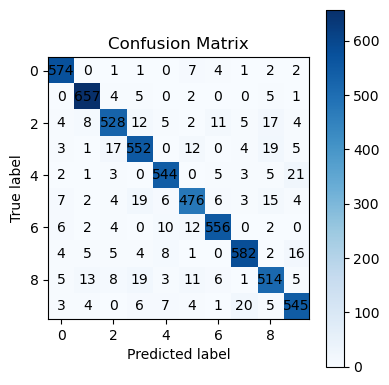

{'category': 'Logistic Regression', 'model_name': 'LogisticRegression_baseline', 'metrics': {'train_metrics': {'accuracy': 0.9392037037037037, 'precision': 0.9390836958427318, 'recall': 0.9392037037037037, 'f1': 0.9391234632446687}, 'validation_metrics': {'accuracy': 0.9213333333333333, 'precision': 0.9212300394352414, 'recall': 0.9213333333333333, 'f1': 0.9211861981414807}, 'scores': {'train_accuracy': 0.9392037037037037, 'validation_accuracy': 0.9213333333333333}}, 'params': {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}, 'data_info': {'n_train': 54000, 'n_validation': 6000}}


In [8]:
#Train baseline model

baseline_model = LogisticRegression(max_iter=500, random_state=42)
baseline_model.fit(X_train, y_train)

y_train_pred = baseline_model.predict(X_train)
y_val_pred   = baseline_model.predict(X_val)

# Evaluation
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="Logistic Regression - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="Logistic Regression - Validation"
)

#Return Results 
results = {
    "train_metrics": train_metrics,
    "validation_metrics": val_metrics,
    "scores": {
        "train_accuracy": train_metrics["accuracy"],
        "validation_accuracy": val_metrics["accuracy"]
    }
}

#Save on json file
save_result(
    model_name="LogisticRegression_baseline",
    category="Logistic Regression",
    metrics=results,
    params=baseline_model.get_params(),
    data_info={
        "n_train": len(X_train),
        "n_validation": len(X_val)
    }
)


In [9]:
# Logestic Regression +  manual tuning for  C= 0.1, 1, 10

In [10]:
from sklearn.linear_model import LogisticRegression

for C in [0.1, 1, 10]:

    model = LogisticRegression(
        C=C,
        max_iter=500,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)

    train_metrics = evaluate_classification(
        y_train, y_train_pred,
        plot=False,
        title=f"LogReg C={C} - Train"
    )

    val_metrics = evaluate_classification(
        y_val, y_val_pred,
        plot=False,
        title=f"LogReg C={C} - Validation"
    )

    results = {
        "train_metrics": train_metrics,
        "validation_metrics": val_metrics,
        "scores": {
            "train_accuracy": train_metrics["accuracy"],
            "validation_accuracy": val_metrics["accuracy"]
        }
    }

    save_result(
        model_name=f"LogReg_C{C}",
        category="Logistic Regression",
        metrics=results,
        params=model.get_params()
    )


===== LogReg C=0.1 - Train =====

Model Evaluation
Accuracy : 0.9324
Precision: 0.9322
Recall   : 0.9324
F1 score : 0.9323

===== LogReg C=0.1 - Validation =====

Model Evaluation
Accuracy : 0.9217
Precision: 0.9216
Recall   : 0.9217
F1 score : 0.9216
{'category': 'Logistic Regression', 'model_name': 'LogReg_C0.1', 'metrics': {'train_metrics': {'accuracy': 0.9323888888888889, 'precision': 0.932231562360222, 'recall': 0.9323888888888889, 'f1': 0.9322701687063395}, 'validation_metrics': {'accuracy': 0.9216666666666666, 'precision': 0.9215825132266117, 'recall': 0.9216666666666666, 'f1': 0.9215573624586207}, 'scores': {'train_accuracy': 0.9323888888888889, 'validation_accuracy': 0.9216666666666666}}, 'params': {'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}}


In [11]:
# KNN + Base line with k =5 


===== KNN (k=5) - Train =====

Model Evaluation
Accuracy : 0.9815
Precision: 0.9816
Recall   : 0.9815
F1 score : 0.9815

===== KNN (k=5) - Validation =====

Model Evaluation
Accuracy : 0.9683
Precision: 0.9686
Recall   : 0.9683
F1 score : 0.9683


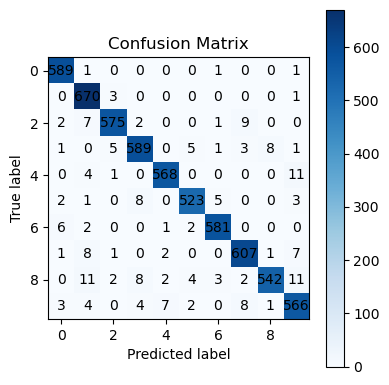

{'category': 'KNN', 'model_name': 'KNN_k5', 'metrics': {'train_metrics': {'accuracy': 0.981537037037037, 'precision': 0.9816297417823262, 'recall': 0.981537037037037, 'f1': 0.9815178137728056}, 'validation_metrics': {'accuracy': 0.9683333333333334, 'precision': 0.9685766892307065, 'recall': 0.9683333333333334, 'f1': 0.9682885858473539}, 'scores': {'train_accuracy': 0.981537037037037, 'validation_accuracy': 0.9683333333333334}, 'overfitting_gap': 0.013203703703703606}, 'params': {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}, 'data_info': {'n_train': 54000, 'n_validation': 6000}}


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_train_pred = knn_model.predict(X_train)
y_val_pred   = knn_model.predict(X_val)

# Evaluation
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="KNN (k=5) - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="KNN (k=5) - Validation"
)

# Return Results

results = {
    "train_metrics": train_metrics,
    "validation_metrics": val_metrics,
    "scores": {
        "train_accuracy": train_metrics["accuracy"],
        "validation_accuracy": val_metrics["accuracy"]
    },
    "overfitting_gap": train_metrics["accuracy"] - val_metrics["accuracy"]
}

# Save on json file
save_result(
    model_name="KNN_k5",
    category="KNN",
    metrics=results,
    params=knn_model.get_params(),
    data_info={
        "n_train": len(X_train),
        "n_validation": len(X_val)
    }
)

In [13]:
# KNN + manual tuning for k=1,3,5

In [14]:
for k in [1, 3, 5]:

    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)

    y_train_pred = knn_model.predict(X_train)
    y_val_pred   = knn_model.predict(X_val)

    train_metrics = evaluate_classification(
        y_train, y_train_pred,
        plot=False,
        title=f"KNN k={k} - Train"
    )

    val_metrics = evaluate_classification(
        y_val, y_val_pred,
        plot=False,
        title=f"KNN k={k} - Validation"
    )

    results = {
        "train_metrics": train_metrics,
        "validation_metrics": val_metrics,
        "scores": {
            "train_accuracy": train_metrics["accuracy"],
            "validation_accuracy": val_metrics["accuracy"]
        },
        "overfitting_gap": train_metrics["accuracy"] - val_metrics["accuracy"]
    }

    save_result(
        model_name=f"KNN_k{k}",
        category="KNN",
        metrics=results,
        params=knn_model.get_params()
    )


===== KNN k=1 - Train =====

Model Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000

===== KNN k=1 - Validation =====

Model Evaluation
Accuracy : 0.9692
Precision: 0.9693
Recall   : 0.9692
F1 score : 0.9691
{'category': 'KNN', 'model_name': 'KNN_k1', 'metrics': {'train_metrics': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, 'validation_metrics': {'accuracy': 0.9691666666666666, 'precision': 0.9692870165725334, 'recall': 0.9691666666666666, 'f1': 0.9691107985952965}, 'scores': {'train_accuracy': 1.0, 'validation_accuracy': 0.9691666666666666}, 'overfitting_gap': 0.03083333333333338}, 'params': {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}}

===== KNN k=3 - Train =====

Model Evaluation
Accuracy : 0.9865
Precision: 0.9866
Recall   : 0.9865
F1 score : 0.9865

===== KNN k=3 - Validation =====

Model Evaluation
Accuracy : 0.9713
Precisio

In [15]:
# Decision Tree + Baseline


===== Decision Tree (Baseline) - Train =====

Model Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000

===== Decision Tree (Baseline) - Validation =====

Model Evaluation
Accuracy : 0.8750
Precision: 0.8746
Recall   : 0.8750
F1 score : 0.8747


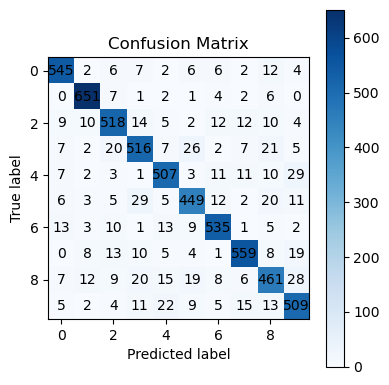

{'category': 'Decision Tree', 'model_name': 'DecisionTree_Baseline', 'metrics': {'train_metrics': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, 'validation_metrics': {'accuracy': 0.875, 'precision': 0.8746265739676784, 'recall': 0.875, 'f1': 0.8747282991706599}, 'scores': {'train_accuracy': 1.0, 'validation_accuracy': 0.875}, 'overfitting_gap': 0.125}, 'params': {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}}


In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predict
y_train_pred = dt_model.predict(X_train)
y_val_pred   = dt_model.predict(X_val)

# Evaluate
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="Decision Tree (Baseline) - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="Decision Tree (Baseline) - Validation"
)

# Save results
results = {
    "train_metrics": train_metrics,
    "validation_metrics": val_metrics,
    "scores": {
        "train_accuracy": train_metrics["accuracy"],
        "validation_accuracy": val_metrics["accuracy"]
    },
    "overfitting_gap": train_metrics["accuracy"] - val_metrics["accuracy"]
}

save_result(
    model_name="DecisionTree_Baseline",
    category="Decision Tree",
    metrics=results,
    params=dt_model.get_params()
)

In [17]:
# ِDecision Tree + manual tuning for  max_depth= 3,5,10,12, 15

In [18]:
from sklearn.tree import DecisionTreeClassifier

for md in [3, 5, 10, 12, 15]:

    dt_model = DecisionTreeClassifier(
        max_depth=md,
        random_state=42
    )

    # Train
    dt_model.fit(X_train, y_train)

    # Predict
    y_train_pred = dt_model.predict(X_train)
    y_val_pred   = dt_model.predict(X_val)

    # Evaluate
    train_metrics = evaluate_classification(
        y_train,
        y_train_pred,
        plot=False,
        title=f"Decision Tree (max_depth={md}) - Train"
    )

    val_metrics = evaluate_classification(
        y_val,
        y_val_pred,
        plot=False,
        title=f"Decision Tree (max_depth={md}) - Validation"
    )

    # Save results
    results = {
        "train_metrics": train_metrics,
        "validation_metrics": val_metrics,
        "scores": {
            "train_accuracy": train_metrics["accuracy"],
            "validation_accuracy": val_metrics["accuracy"]
        },
        "overfitting_gap": train_metrics["accuracy"] - val_metrics["accuracy"]
    }

    save_result(
        model_name=f"DecisionTree_md{md}",
        category="Decision Tree",
        metrics=results,
        params=dt_model.get_params()
    )


===== Decision Tree (max_depth=3) - Train =====

Model Evaluation
Accuracy : 0.4889
Precision: 0.4050
Recall   : 0.4889
F1 score : 0.4301

===== Decision Tree (max_depth=3) - Validation =====

Model Evaluation
Accuracy : 0.4862
Precision: 0.4010
Recall   : 0.4862
F1 score : 0.4266
{'category': 'Decision Tree', 'model_name': 'DecisionTree_md3', 'metrics': {'train_metrics': {'accuracy': 0.48885185185185187, 'precision': 0.40498381158625935, 'recall': 0.48885185185185187, 'f1': 0.43010379020947054}, 'validation_metrics': {'accuracy': 0.4861666666666667, 'precision': 0.40095011231074934, 'recall': 0.4861666666666667, 'f1': 0.4265837711180659}, 'scores': {'train_accuracy': 0.48885185185185187, 'validation_accuracy': 0.4861666666666667}, 'overfitting_gap': 0.0026851851851851793}, 'params': {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'mi

In [19]:
# Optimisation with  GridsearchCV and k-fold cross valiadation

In [20]:

def _as_arrays(X, y):
    X_arr = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)
    return X_arr, y_arr


def plot_kfold_summary(results, title_prefix=""):
    metrics = ["accuracy", "precision", "recall", "f1"]

    means = [results["mean"][m] for m in metrics]
    stds  = [results["std"][m] for m in metrics]

    plt.figure(figsize=(7,5))
    plt.bar(metrics, means, yerr=stds, capsize=5)
    plt.title(f"{title_prefix} K-Fold CV Summary (Mean ± Std)")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.show()

In [21]:
def kfold_cv(model, X, y, k=5, plot=True, title_prefix="", save_path=None):
    
    X_arr, y_arr = _as_arrays(X, y)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    accs, precs, recs, f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), 1):

        X_tr, X_va = X_arr[train_idx], X_arr[val_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_va)

        accs.append(accuracy_score(y_va, y_pred))
        precs.append(precision_score(y_va, y_pred, average="macro", zero_division=0))
        recs.append(recall_score(y_va, y_pred, average="macro", zero_division=0))
        f1s.append(f1_score(y_va, y_pred, average="macro", zero_division=0))

    results = {
        "model": str(model),
        "k": k,
        "per_fold": {
            "accuracy": accs,
            "precision": precs,
            "recall": recs,
            "f1": f1s
        },
        "mean": {
            "accuracy": float(np.mean(accs)),
            "precision": float(np.mean(precs)),
            "recall": float(np.mean(recs)),
            "f1": float(np.mean(f1s))
        },
        "std": {
            "accuracy": float(np.std(accs)),
            "precision": float(np.std(precs)),
            "recall": float(np.std(recs)),
            "f1": float(np.std(f1s))
        },
        "stability_score": float(1 - np.std(accs))
    }

    # print summary
    print(f"\n{k}-Fold CV Results")
    print(f"Accuracy : {results['mean']['accuracy']:.4f}")
    print(f"Precision: {results['mean']['precision']:.4f}")
    print(f"Recall   : {results['mean']['recall']:.4f}")
    print(f"F1       : {results['mean']['f1']:.4f}")
    print(f"Std      : {results['std']['accuracy']:.4f}")

    # plots
    if plot:
        plot_kfold_summary(results, title_prefix)

    # save JSON
    if save_path:
        with open(save_path, "w") as f:
            json.dump(results, f, indent=4)

    return results

In [22]:
# Logestic Regression Hyperparameter tuning 

In [23]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.01, 0.05, 0.1, 0.2, 0.5],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)


grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

results_df = pd.DataFrame(grid.cv_results_)

pivot = results_df.pivot(
    index="param_C",
    columns="param_solver",
    values="mean_test_score"
)

print("\nScore matrix (rows=C, cols=solver):")
print(pivot.round(4))
#best_lr = grid.best_estimator_

Best parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV score: 0.9196358920296875

Score matrix (rows=C, cols=solver):
param_solver   lbfgs
param_C             
0.01          0.9086
0.05          0.9180
0.10          0.9196
0.20          0.9196
0.50          0.9190


In [72]:
best_lr = grid.best_estimator_

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

5-Fold CV Results
Accuracy : 0.9207
Precision: 0.9197
Recall   : 0.9196
F1       : 0.9196
Std      : 0.0031


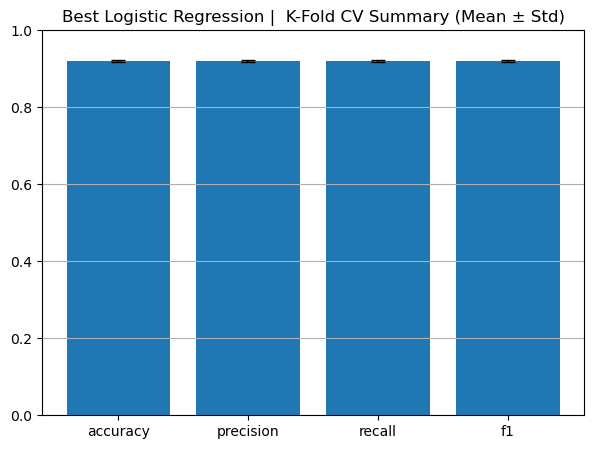

In [89]:
best_model = grid.best_estimator_

print(best_model)

lr_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=True,
    title_prefix="Best Logistic Regression | "
)

In [25]:
# KNN Hyperparameter tuning with gridsearch 

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd

param_grid = {
    "n_neighbors": [3, 5],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

# Results
print("Best parameters:", grid_knn.best_params_)
print("Best CV score:", grid_knn.best_score_)
 # Save on json file
results_df = pd.DataFrame(grid_knn.cv_results_)

pivot = results_df.pivot(
    index="param_n_neighbors",
    columns="param_weights",
    values="mean_test_score"
)

print("\nScore matrix (rows=n_neighbors, cols=weights):")
print(pivot.round(4))

# Best model
best_knn = grid_knn.best_estimator_

Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.969308115130902

Score matrix (rows=n_neighbors, cols=weights):
param_weights      distance  uniform
param_n_neighbors                   
3                    0.9693   0.9678
5                    0.9691   0.9677


In [79]:
best_knn = grid_knn.best_estimator_

KNeighborsClassifier(n_neighbors=3, weights='distance')

5-Fold CV Results
Accuracy : 0.9716
Precision: 0.9719
Recall   : 0.9712
F1       : 0.9714
Std      : 0.0012


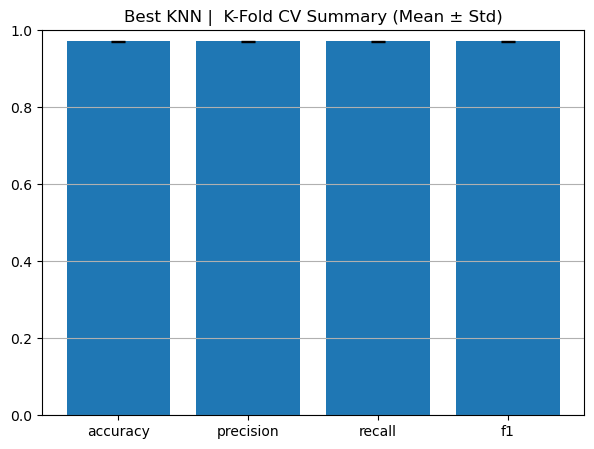

In [27]:
# K-fold Cross Validation
best_model = grid_knn.best_estimator_
print(best_model)

knn_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=True,
    title_prefix="Best KNN | "
)

In [28]:
#ِDecision Tree hyper parametee tuning with gridsearch

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

param_grid = {
    "max_depth": [10, 12, 20],
    "min_samples_split": [2, 5]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best CV score:", grid_dt.best_score_)

results_df = pd.DataFrame(grid_dt.cv_results_)

pivot = results_df.pivot(
    index="param_max_depth",
    columns="param_min_samples_split",
    values="mean_test_score"
)

print("\nScore matrix:")
print(pivot.round(4))
best_dt = grid_dt.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_split': 2}
Best CV score: 0.8581370037871348

Score matrix:
param_min_samples_split       2       5
param_max_depth                        
10                       0.8477  0.8468
12                       0.8580  0.8573
20                       0.8581  0.8569


DecisionTreeClassifier(max_depth=20, random_state=42)

5-Fold CV Results
Accuracy : 0.8654
Precision: 0.8636
Recall   : 0.8636
F1       : 0.8635
Std      : 0.0020


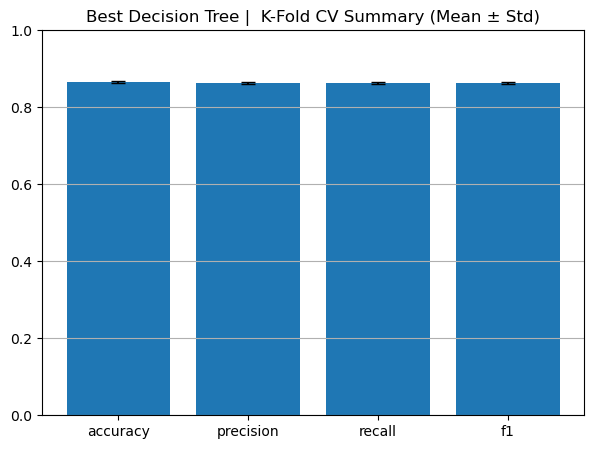

In [30]:
best_model = grid_dt.best_estimator_
print(best_model)

dt_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=True,
    title_prefix="Best Decision Tree | "
)

In [31]:
# Best of Models that I add manually based on previous sections 

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
best_lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance')

best_dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    random_state=42)


In [33]:
# Ensemble + Soft voting based on best parameters od all Models

In [34]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('knn', best_knn),
        ('dt', best_dt)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True



5-Fold CV Results
Accuracy : 0.9583
Precision: 0.9580
Recall   : 0.9577
F1       : 0.9578
Std      : 0.0017


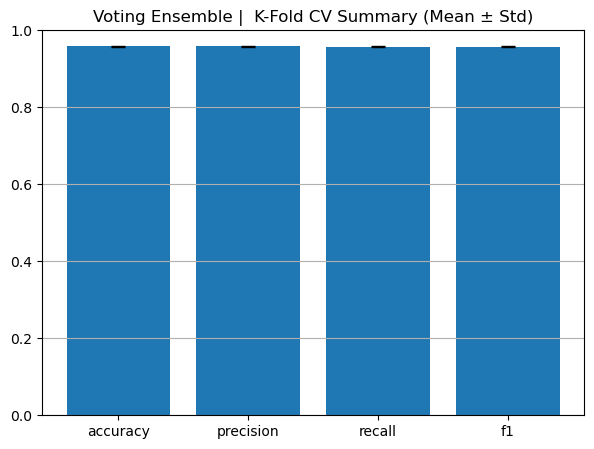

{'model': "VotingClassifier(estimators=[('lr',\n                              LogisticRegression(C=0.1, max_iter=1000,\n                                                 random_state=42)),\n                             ('knn',\n                              KNeighborsClassifier(n_neighbors=3,\n                                                   weights='distance')),\n                             ('dt',\n                              DecisionTreeClassifier(max_depth=20,\n                                                     random_state=42))],\n                 voting='soft')",
 'k': 5,
 'per_fold': {'accuracy': [0.9598148148148148,
   0.9557407407407408,
   0.960462962962963,
   0.9575,
   0.9578703703703704],
  'precision': [0.9595693293535718,
   0.9552959251574882,
   0.9602990859229832,
   0.9571993307339859,
   0.9577146323748471],
  'recall': [0.9593426546783208,
   0.9549735449924391,
   0.9600115428082369,
   0.9567203230284094,
   0.9573702664655432],
  'f1': [0.9594146361770417,

In [35]:
kfold_cv(
    voting_clf,
    X_train,
    y_train,
    k=5,
    plot=True,
    title_prefix="Voting Ensemble | "
)

In [36]:
# Add metrics manually based on previous sections 

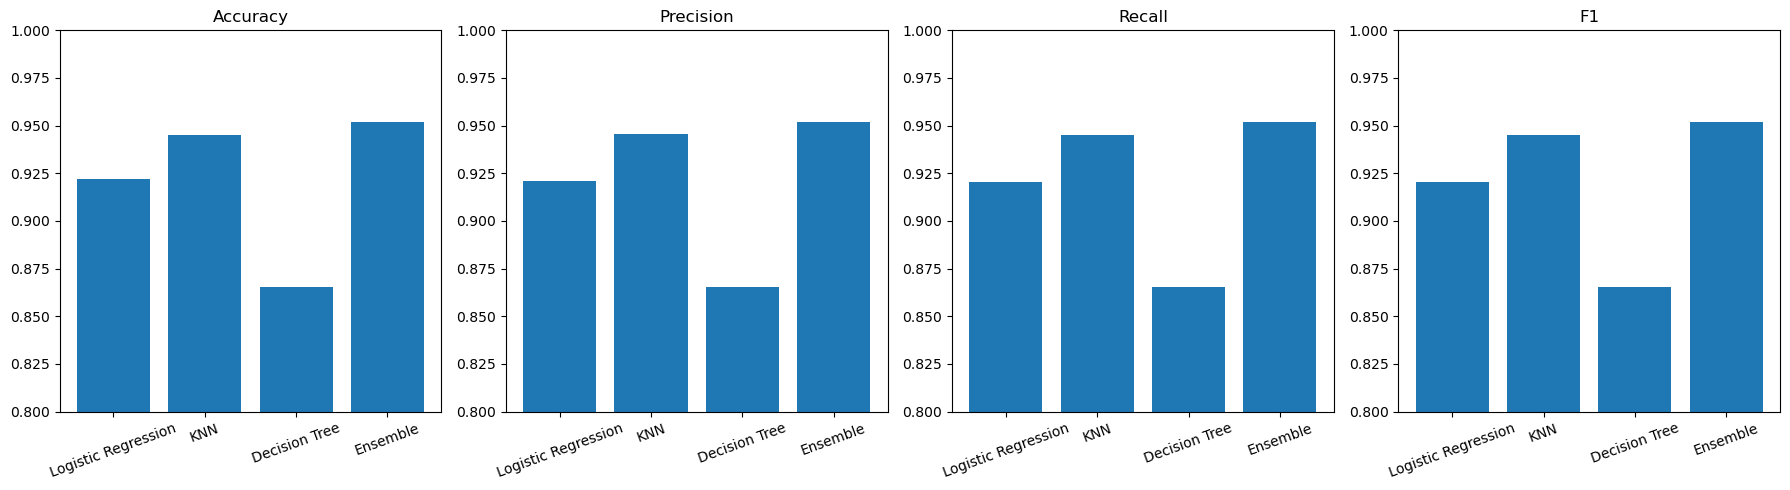

In [37]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9218,
        "Precision": 0.9210,
        "Recall": 0.9207,
        "F1": 0.9207,
        "Std": 0.0040
    },
    {
        "Model": "KNN",
        "Accuracy": 0.9716,
        "Precision": 0.9719,
        "Recall": 0.9712,
        "F1": 0.9714,
        "Std": 0.0011
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.8654,
        "Precision": 0.8636,
        "Recall": 0.8636,
        "F1": 0.8635,
        "Std": 0.0020
    },
    {
        "Model": "Ensemble",
        "Accuracy": 0.9583,
        "Precision": 0.9500,
        "Recall": 0.9577,
        "F1": 0.9578,
        "Std": 0.0007
    }
])



metrics = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(results["Model"], results[metric])
    axes[i].set_title(metric)
    axes[i].set_ylim(0.8, 1.0)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Now work on TEST dataset 

In [85]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "Ensemble": voting_clf
}

results = {}

for name, model in models.items():
    
    # predict on test set
    y_pred = model.predict(X_test)
    
    # metrics
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }
    
    print("\n" + "="*50)
    print(name)
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.94      0.89      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.89      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


KNN
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.96      0.97      103

In [87]:

df_results = pd.DataFrame(results).T
print(df_results.sort_values(by="f1", ascending=False))

                     accuracy  precision    recall        f1
KNN                    0.9709   0.971090  0.970555  0.970726
Ensemble               0.9578   0.957519  0.957254  0.957326
Logistic Regression    0.9247   0.923782  0.923581  0.923552
Decision Tree          0.8698   0.867991  0.867959  0.867889


### Load the model results for comparison

In [ ]:
### ../results/final_comparison.ipynb

In [ ]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
c = 5
penalty = 1.3
results = {
    "model": "LG",
    "best_params": {"C": int(c), "penalty": penalty},
    "metrics": {
        "accuracy": 0.6,
        "precision": 0.57,
        "recall": 0.88,
        "f1": 0.8,
    },
    "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
}
with open("../results/logisticReg.json", "w") as f:
    json.dump(results, f, indent=2)